#Project :  Library Usage Analytics
#Domain : Education

Goal : The goal of this project is to analyze students library usage patterns to understand borrowing behavior, identify underutilized book categories, and provide insights to help the library optimize its resources and improve student engagement.

In [24]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")


In [25]:
!pip install simple_colors
from simple_colors import *
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [26]:
raw=pd.read_excel("/Library_Usage_Analytics.xlsx")

In [27]:
raw

,Student_ID,Student_Name,Department,Year,Book_ID,Book_Title,Category,Borrow_Date,Return_Date,Days_Borrowed,Fine_Amount,Rating
0,S0001,Joshua Smith,CSE,1st,B6245,There,Fiction,2024-12-29,2025-01-23,25,43.54,3
1,S0002,Nicholas Jones,MBA,2nd,B8722,Full course read,Fiction,2024-11-20,2024-11-29,9,0.00,5
2,S0003,Andrea Castillo,CSE,2nd,B5910,Education resource smile,Philosophy,2025-06-24,2025-07-15,21,9.09,1
3,S0004,Kelly Anderson,CIVIL,3rd,B7427,Make,Data Science,2024-10-27,2024-11-09,13,0.00,1
4,S0005,Mary Esparza,CSE,1st,B8573,Send today,AI & ML,2025-09-26,2025-10-21,25,15.68,2
...,...,...,...,...,...,...,...,...,...,...,...,...
5995,S5996,Danielle Phillips,MBA,3rd,B8849,Stand result,AI & ML,2025-05-28,2025-06-04,7,0.00,5
5996,S5997,Jeanne Rodriguez,CSE,2nd,B4632,Off better,History,2024-12-07,2024-12-31,24,20.31,1
5997,S5998,Jesse Turner,ENGLISH,3rd,B5030,Sport war appear,Engineering,2024-10-31,2024-11-09,9,0.00,4
5998,S5999,William Reese,ECE,3rd,B6765,Should might,Literature,2023-11-27,2023-12-14,17,14.27,1


#Data info :
The dataset contains information about 6,000 students and their interactions with the library. It consists of 12 columns, capturing both student details and their borrowing behavior. The dataset can be used to analyze borrowing patterns, identify popular and underutilized book categories, and optimize library resources

In [28]:
raw.head()

,Student_ID,Student_Name,Department,Year,Book_ID,Book_Title,Category,Borrow_Date,Return_Date,Days_Borrowed,Fine_Amount,Rating
0,S0001,Joshua Smith,CSE,1st,B6245,There,Fiction,2024-12-29,2025-01-23,25,43.54,3
1,S0002,Nicholas Jones,MBA,2nd,B8722,Full course read,Fiction,2024-11-20,2024-11-29,9,0.00,5
2,S0003,Andrea Castillo,CSE,2nd,B5910,Education resource smile,Philosophy,2025-06-24,2025-07-15,21,9.09,1
3,S0004,Kelly Anderson,CIVIL,3rd,B7427,Make,Data Science,2024-10-27,2024-11-09,13,0.00,1
4,S0005,Mary Esparza,CSE,1st,B8573,Send today,AI & ML,2025-09-26,2025-10-21,25,15.68,2


In [29]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Student_ID     6000 non-null   object        
 1   Student_Name   6000 non-null   object        
 2   Department     6000 non-null   object        
 3   Year           6000 non-null   object        
 4   Book_ID        6000 non-null   object        
 5   Book_Title     6000 non-null   object        
 6   Category       6000 non-null   object        
 7   Borrow_Date    6000 non-null   datetime64[ns]
 8   Return_Date    6000 non-null   datetime64[ns]
 9   Days_Borrowed  6000 non-null   int64         
 10  Fine_Amount    6000 non-null   float64       
 11  Rating         6000 non-null   int64         
dtypes: datetime64[ns](2), float64(1), int64(2), object(7)
memory usage: 562.6+ KB


1.Data Validation



*   convert  cats to lowercase

*   validation of data column with datatypes

*   find duplicates





In [30]:
for col in raw.select_dtypes("O"):
  raw[col]=raw[col].str.lower()

In [31]:
raw.head()

,Student_ID,Student_Name,Department,Year,Book_ID,Book_Title,Category,Borrow_Date,Return_Date,Days_Borrowed,Fine_Amount,Rating
0,s0001,joshua smith,cse,1st,b6245,there,fiction,2024-12-29,2025-01-23,25,43.54,3
1,s0002,nicholas jones,mba,2nd,b8722,full course read,fiction,2024-11-20,2024-11-29,9,0.00,5
2,s0003,andrea castillo,cse,2nd,b5910,education resource smile,philosophy,2025-06-24,2025-07-15,21,9.09,1
3,s0004,kelly anderson,civil,3rd,b7427,make,data science,2024-10-27,2024-11-09,13,0.00,1
4,s0005,mary esparza,cse,1st,b8573,send today,ai & ml,2025-09-26,2025-10-21,25,15.68,2


In [32]:
for col in raw.columns:
    print(yellow(f"Column: {col}", ['bold']))
    unique_vals = raw[col].unique()
    n_unique = len(unique_vals)

    print(red(f"Number of Unique Values in Column: {n_unique}", ['bold']))
    print(green("Unique Values:", ['bold']))

    # if too many unique values, show first 100 only, and save full list to file
    if n_unique > 100:
        print(unique_vals[:100])
        print(yellow(f"Showing only first 100 unique values (full list saved to '{col}_unique_values.txt')", ['bold']))
        # Save all unique values to a text file
        with open(f"{col}_unique_values.txt", "w", encoding="utf-8") as f:
            for val in unique_vals:
                f.write(str(val) + "\n")
    else:
        print(unique_vals)

    print(yellow(f"Data Type of Column: {raw[col].dtype}", ['bold']))
    print()


Column: Student_ID
Number of Unique Values in Column: 6000
Unique Values:
['s0001' 's0002' 's0003' 's0004' 's0005' 's0006' 's0007' 's0008' 's0009'
 's0010' 's0011' 's0012' 's0013' 's0014' 's0015' 's0016' 's0017' 's0018'
 's0019' 's0020' 's0021' 's0022' 's0023' 's0024' 's0025' 's0026' 's0027'
 's0028' 's0029' 's0030' 's0031' 's0032' 's0033' 's0034' 's0035' 's0036'
 's0037' 's0038' 's0039' 's0040' 's0041' 's0042' 's0043' 's0044' 's0045'
 's0046' 's0047' 's0048' 's0049' 's0050' 's0051' 's0052' 's0053' 's0054'
 's0055' 's0056' 's0057' 's0058' 's0059' 's0060' 's0061' 's0062' 's0063'
 's0064' 's0065' 's0066' 's0067' 's0068' 's0069' 's0070' 's0071' 's0072'
 's0073' 's0074' 's0075' 's0076' 's0077' 's0078' 's0079' 's0080' 's0081'
 's0082' 's0083' 's0084' 's0085' 's0086' 's0087' 's0088' 's0089' 's0090'
 's0091' 's0092' 's0093' 's0094' 's0095' 's0096' 's0097' 's0098' 's0099'
 's0100']
Showing only first 100 unique values (full list saved to 'Student_ID_unique_values.txt')
Data Type of Column: obj

In [33]:
raw.duplicated().any()


np.False_

#2.EDA (Data Insights from stats methods)

2.1 **Univariate Analysis**

In [34]:
from google.colab import files
uploaded = files.upload()


Saving eda.py to eda (1).py


In [35]:
from eda import Univariate

In [36]:
raw.dtypes

,0
Student_ID,object
Student_Name,object
Department,object
Year,object
Book_ID,object
Book_Title,object
Category,object
Borrow_Date,datetime64[ns]
Return_Date,datetime64[ns]
Days_Borrowed,int64


Enter Numeric Discrete Column Names Seperated by Commas: 1

#######################################################
Column:  Student_ID (Categorical)

            Uni-Variate Descriptive Stats              
#######################################################

Number of Categories/Classes in column: 6000
Category Names:
['s0001' 's0002' 's0003' ... 's5998' 's5999' 's6000']

Value Counts (FD) of each Category:
Student_ID
s5984    1
s5983    1
s5982    1
s5981    1
s5980    1
        ..
s0005    1
s0004    1
s0003    1
s0002    1
s0001    1
Name: count, Length: 6000, dtype: int64

Value Counts of Each Class (FD) as Percentage:
Student_ID
s5984   0.02
s5983   0.02
s5982   0.02
s5981   0.02
s5980   0.02
        ... 
s0005   0.02
s0004   0.02
s0003   0.02
s0002   0.02
s0001   0.02
Name: count, Length: 6000, dtype: float64

Measures of Central Tendancy:
Mode: s0001

             Visual (Top Categories)             
#######################################################



#######################################################
Column:  Student_Name (Categorical)

            Uni-Variate Descriptive Stats              
#######################################################

Number of Categories/Classes in column: 5761
Category Names:
['joshua smith' 'nicholas jones' 'andrea castillo' ... 'jesse turner'
 'william reese' 'carrie patterson']

Value Counts (FD) of each Category:
Student_Name
michael johnson    4
jonathan smith     4
james johnson      4
david brown        3
james williams     3
                  ..
richard cox        1
katherine davis    1
scott mack         1
patricia potter    1
natalie wright     1
Name: count, Length: 5761, dtype: int64

Value Counts of Each Class (FD) as Percentage:
Student_Name
michael johnson   0.07
jonathan smith    0.07
james johnson     0.07
david brown       0.05
james williams    0.05
                  ... 
richard cox       0.02
katherine davis   0.02
scott mack        0.02
patricia potter   0.02
natalie wrigh


#######################################################
Column:  Department (Categorical)

            Uni-Variate Descriptive Stats              
#######################################################

Number of Categories/Classes in column: 6
Category Names:
['cse' 'mba' 'civil' 'english' 'ece' 'mech']

Value Counts (FD) of each Category:
Department
mech       1044
ece        1034
cse         994
english     980
mba         976
civil       972
Name: count, dtype: int64

Value Counts of Each Class (FD) as Percentage:
Department
mech      17.40
ece       17.23
cse       16.57
english   16.33
mba       16.27
civil     16.20
Name: count, dtype: float64

Measures of Central Tendancy:
Mode: mech

             Visual (Top Categories)             
#######################################################



#######################################################
Column:  Year (Categorical)

            Uni-Variate Descriptive Stats              
#######################################################

Number of Categories/Classes in column: 4
Category Names:
['1st' '2nd' '3rd' '4th']

Value Counts (FD) of each Category:
Year
4th    1532
1st    1508
2nd    1483
3rd    1477
Name: count, dtype: int64

Value Counts of Each Class (FD) as Percentage:
Year
4th   25.53
1st   25.13
2nd   24.72
3rd   24.62
Name: count, dtype: float64

Measures of Central Tendancy:
Mode: 4th

             Visual (Top Categories)             
#######################################################



#######################################################
Column:  Book_ID (Categorical)

            Uni-Variate Descriptive Stats              
#######################################################

Number of Categories/Classes in column: 4457
Category Names:
['b6245' 'b8722' 'b5910' ... 'b1493' 'b3697' 'b6765']

Value Counts (FD) of each Category:
Book_ID
b4745    6
b5787    5
b6328    5
b5439    5
b8946    4
        ..
b7411    1
b4935    1
b8521    1
b1493    1
b3697    1
Name: count, Length: 4457, dtype: int64

Value Counts of Each Class (FD) as Percentage:
Book_ID
b4745   0.10
b5787   0.08
b6328   0.08
b5439   0.08
b8946   0.07
        ... 
b7411   0.02
b4935   0.02
b8521   0.02
b1493   0.02
b3697   0.02
Name: count, Length: 4457, dtype: float64

Measures of Central Tendancy:
Mode: b4745

             Visual (Top Categories)             
#######################################################



#######################################################
Column:  Book_Title (Categorical)

            Uni-Variate Descriptive Stats              
#######################################################

Number of Categories/Classes in column: 5888
Category Names:
['there' 'full course read' 'education resource smile' ...
 'sport war appear' 'should might' 'when hundred three']

Value Counts (FD) of each Category:
Book_Title
manager                       3
democrat                      3
general                       3
phone                         3
seven                         3
                             ..
officer major                 1
here and                      1
risk item necessary           1
concern action guy believe    1
various fear                  1
Name: count, Length: 5888, dtype: int64

Value Counts of Each Class (FD) as Percentage:
Book_Title
manager                      0.05
democrat                     0.05
general                      0.05
phone            


#######################################################
Column:  Category (Categorical)

            Uni-Variate Descriptive Stats              
#######################################################

Number of Categories/Classes in column: 8
Category Names:
['fiction' 'philosophy' 'data science' 'ai & ml' 'engineering'
 'literature' 'history' 'management']

Value Counts (FD) of each Category:
Category
data science    818
engineering     802
history         772
fiction         756
literature      747
ai & ml         720
management      697
philosophy      688
Name: count, dtype: int64

Value Counts of Each Class (FD) as Percentage:
Category
data science   13.63
engineering    13.37
history        12.87
fiction        12.60
literature     12.45
ai & ml        12.00
management     11.62
philosophy     11.47
Name: count, dtype: float64

Measures of Central Tendancy:
Mode: data science

             Visual (Top Categories)             
####################################################


#######################################################
Column:  Borrow_Date (DateTime)

            Uni-Variate Descriptive Stats              
#######################################################

Measures of Dispersion:
Start Date: 2023-10-14 00:00:00
End Date: 2025-10-13 00:00:00
Total Time Period (in Years): 730 days 00:00:00

Date Wise Count:
Borrow_Date
2024-04-30    17
2024-09-13    17
2025-05-28    16
2024-09-12    16
2025-03-14    16
              ..
2023-11-08     2
2024-04-09     2
2024-10-06     2
2025-05-09     2
2024-03-03     2
Name: count, Length: 731, dtype: int64

#######################################################
Column:  Return_Date (DateTime)

            Uni-Variate Descriptive Stats              
#######################################################

Measures of Dispersion:
Start Date: 2023-10-16 00:00:00
End Date: 2025-11-07 00:00:00
Total Time Period (in Years): 753 days 00:00:00

Date Wise Count:
Return_Date
2024-02-20    19
2025-07-18    17
2024-0

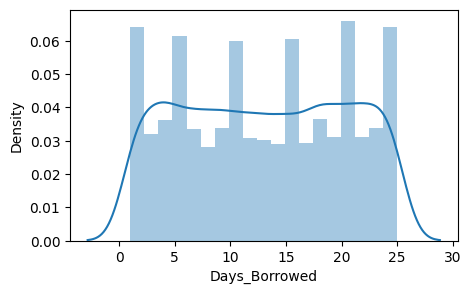


#######################################################
Column:  Fine_Amount (Numeric Continuous)

            Uni-Variate Descriptive Stats              
#######################################################

Measures of Central Tendancy:
Mean: 7.99
Median: 0.0
Mode: 0.0

Measures of Dispersion:
Range: 54.45
Variance: 143.81
Standard Deviation: 11.99
Five Number Summary:
min    0.00
25%    0.00
50%    0.00
75%   13.66
max   54.45
Name: Fine_Amount, dtype: float64

Measures of Symmetry:
Skewness: 1.53
Kurtosis: 1.52

                           Visual             
#######################################################


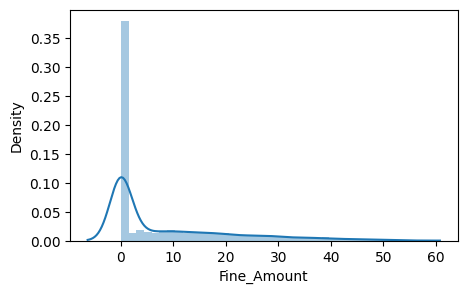


#######################################################
Column:  Rating (Numeric Continuous)

            Uni-Variate Descriptive Stats              
#######################################################

Measures of Central Tendancy:
Mean: 2.96
Median: 3.0
Mode: 1

Measures of Dispersion:
Range: 4
Variance: 2.01
Standard Deviation: 1.42
Five Number Summary:
min   1.00
25%   2.00
50%   3.00
75%   4.00
max   5.00
Name: Rating, dtype: float64

Measures of Symmetry:
Skewness: 0.04
Kurtosis: -1.31

                           Visual             
#######################################################


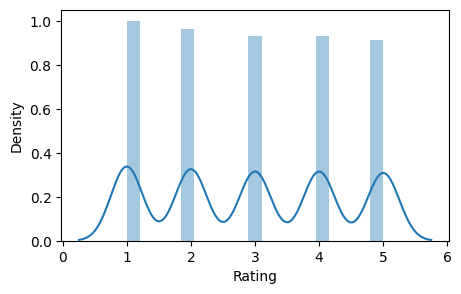

In [37]:
Univariate(raw)

##**Insights**

**Student_Id**

Every record belongs to a distinct student, meaning the dataset represents 6000 unique borrowing instances (no duplicates).

**Student_Name**

 Top Borrowers: Names like Michael Johnson, Jonathan Smith, and James Johnson appeared most often (4 times each).

 A few students are frequent borrowers; library engagement is slightly concentrated among active users.


 **Department**

 Distribution is balanced across departments — no heavy skew.

 **Year**

 Slight dominance from final-year (4th) students, possibly for projects or research.

 **Book_ID**

 Some books are in high demand; potential for increasing copies of popular books.

 **Book_Title**

 Very wide variety of books — indicates diverse reading interests among students.

**Category**

Most borrowed categories: Data Science and Engineering.

Least borrowed: Philosophy and Management.

**Borrow_Date**

Range: Oct 2023 → Oct 2025 (2 years).

Borrowing activity spans continuously — stable usage across semesters.

Peak borrowing dates (17/day) seen in mid-semester months like April, Sept, May.

**Return_Date**

Range: Oct 2023 → Nov 2025.

Return activity is frequent, and no major delays — suggests good compliance.

Most returns around February, June, and December (semester ends).

**Days_Borrowed**

Average borrow duration is ~13 days — close to 2 weeks.

Low skewness (-0.01) → symmetric distribution.

**Fine_Amount**

Over half of students have no fines (median = 0).

**Rating**

Average book rating is ≈3/5 → moderate satisfaction.


In [38]:

dt = raw.copy()


dt['Year'] = dt['Year'].replace({
    '1st': 1,
    '2nd': 2,
    '3rd': 3,
    '4th': 4
})

print(dt['Year'].head())
print(dt.dtypes)


0    1
1    2
2    2
3    3
4    1
Name: Year, dtype: int64
Student_ID               object
Student_Name             object
Department               object
Year                      int64
Book_ID                  object
Book_Title               object
Category                 object
Borrow_Date      datetime64[ns]
Return_Date      datetime64[ns]
Days_Borrowed             int64
Fine_Amount             float64
Rating                    int64
dtype: object


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

**2.2 Bi/Multi - variate analysis**

**Pure Numeric** :







1. Days Borrowed  vs  Fine Amount


2. Year  vs  Fine Amount


3. Year  vs  Days Borrowed






In [40]:

display(round(raw[["Days_Borrowed","Fine_Amount"]].corr(),2))

,Days_Borrowed,Fine_Amount
Days_Borrowed,1.00,0.79
Fine_Amount,0.79,1.00


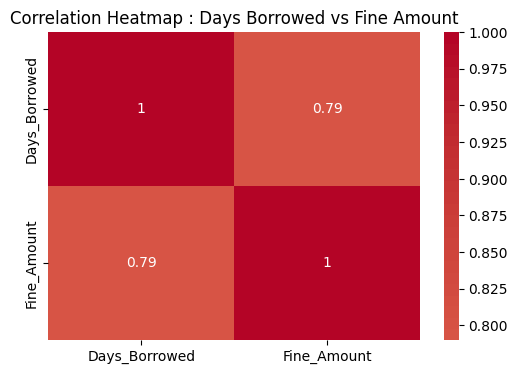

In [41]:
plt.figure(figsize=(6,4))
sns.heatmap(dt[['Days_Borrowed', 'Fine_Amount']].corr().round(2), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap : Days Borrowed vs Fine Amount")
plt.show()

#**Insights**
**Strong Positive Correlation (r = 0.79):**

As the number of days a book is borrowed increases, the fine amount also rises significantly, showing a strong direct relationship between the two.

**Predictive Insight:**

This pattern can help predict potential late returns or automate fine calculation systems based on borrowing duration, improving library management efficiency.


In [42]:
display(round(dt[["Year","Fine_Amount"]].corr(),2))

,Year,Fine_Amount
Year,1.00,0.01
Fine_Amount,0.01,1.00


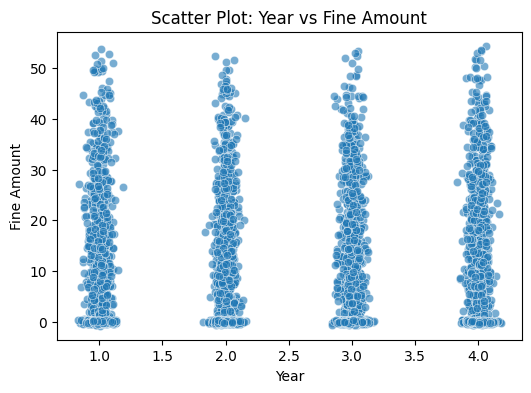

In [43]:
import numpy as np

plt.figure(figsize=(6,4))
sns.scatterplot(
    x=dt['Year'] + np.random.normal(0, 0.05, size=len(dt)),  # small x-jitter
    y=dt['Fine_Amount'] + np.random.normal(0, 0.2, size=len(dt)),  # small y-jitter
    alpha=0.6
)
plt.title("Scatter Plot: Year vs Fine Amount")
plt.xlabel("Year")
plt.ylabel("Fine Amount")
plt.show()


#**Insights**
**Weak Correlation (r = 0.01):**

There is almost no linear relationship between the student’s academic year and the fine amount, suggesting that fines are not dependent on whether the student is in 1st, 2nd, 3rd, or 4th year.

**Equal Borrowing Discipline:**

All academic years appear to follow similar borrowing and return habits — senior students are not necessarily more punctual or careless than juniors.


In [44]:
display(round(dt[["Year","Days_Borrowed"]].corr(),2))

,Year,Days_Borrowed
Year,1.00,0.02
Days_Borrowed,0.02,1.00


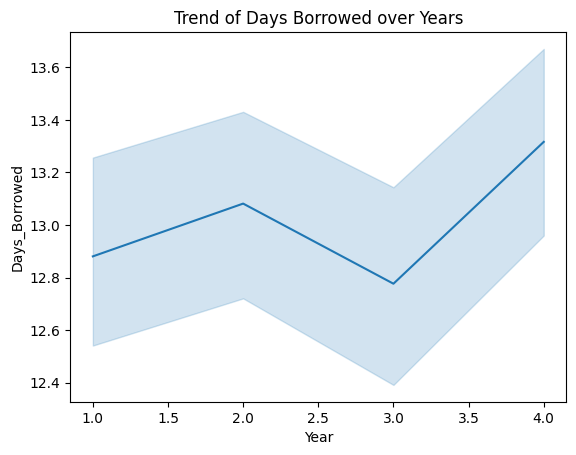

In [45]:
sns.lineplot(data=dt, x="Year", y="Days_Borrowed")
plt.title("Trend of Days Borrowed over Years")
plt.show()


#**Insights**
**Negligible Correlation (r = 0.02):**

There is almost no relationship between the academic year of a student and the number of days they borrow books. This suggests borrowing duration is not influenced by their year of study.

**Consistent Borrowing Habits:**

Students across all academic years (1st–4th) tend to borrow books for roughly similar durations, indicating uniform library engagement policies or similar academic workloads regarding reading time.


**Mixed**



1.   Category vs Year

1.   Category vs Days Borrowed
2.   Department vs Fine Amount
2.   Year vs Fine Amount
5. Category vs Rating
6. Category vs Fine Amount



In [46]:
display(round(dt.groupby('Category')['Year'].describe(),2))

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
ai & ml,720.00,2.49,1.12,1.00,1.00,3.00,3.00,4.00
data science,818.00,2.49,1.13,1.00,1.00,2.50,3.75,4.00
engineering,802.00,2.51,1.12,1.00,2.00,2.00,4.00,4.00
fiction,756.00,2.49,1.14,1.00,1.00,2.00,4.00,4.00
history,772.00,2.50,1.12,1.00,2.00,2.00,4.00,4.00
literature,747.00,2.45,1.12,1.00,1.00,2.00,3.00,4.00
management,697.00,2.59,1.12,1.00,2.00,3.00,4.00,4.00
philosophy,688.00,2.53,1.13,1.00,1.75,3.00,4.00,4.00


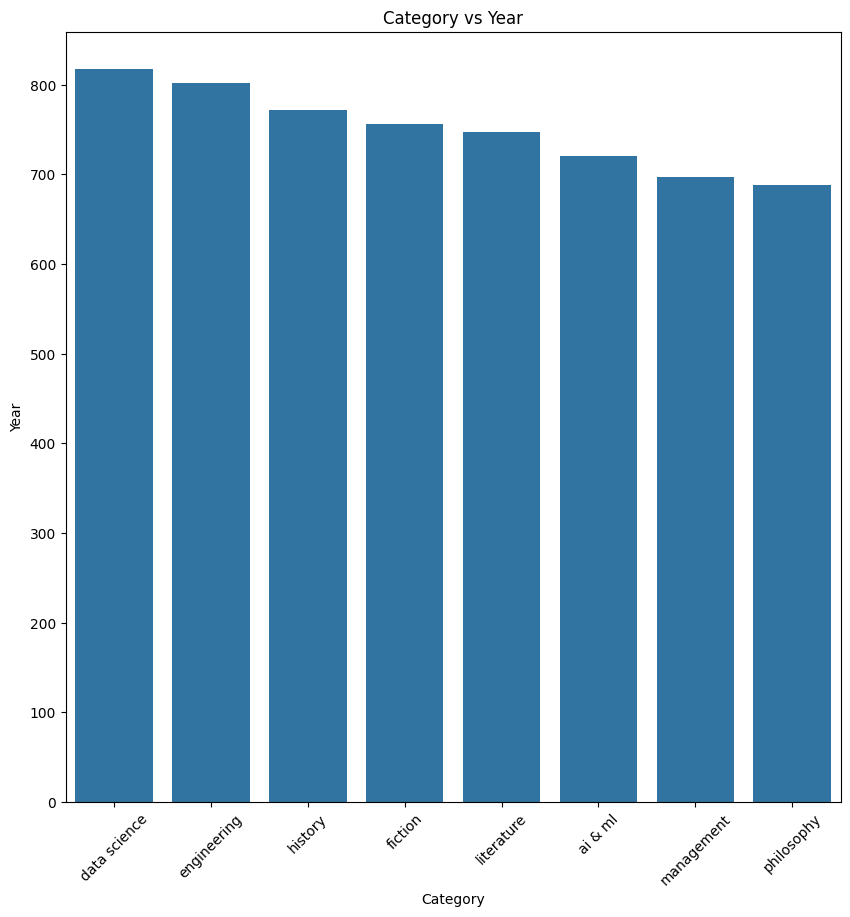

In [70]:
plt.figure(figsize=(10,10))
group = dt.groupby("Category", as_index=False)["Year"].count().sort_values("Year", ascending=False).head(10)
sns.barplot(data=group, x="Category", y="Year")
plt.title("Category vs Year")
plt.xticks(rotation=45)
plt.show()


#**Insights**

Certain categories (like Data Science and AI) are more popular among senior students, showing advanced-level academic interest in later years.

Literature and History books are borrowed more by 1st and 2nd-year students, possibly for foundational or elective courses.



In [71]:
display(round(raw.groupby("Category")["Days_Borrowed"].count(),2))

,Days_Borrowed
Category,
ai & ml,720
data science,818
engineering,802
fiction,756
history,772
literature,747
management,697
philosophy,688


In [49]:
group = round(dt.groupby("Category", as_index=False)["Days_Borrowed"].count(),2)
px.pie(group, names='Category', values='Days_Borrowed', width=600, height=350)

#**Insights**

Technical categories such as Data Science and En gineering show longer borrowing durations, indicating deeper study or project-based usage.

Management and Philosopy categories have shorter borrowing durations, showing they are used mostly for leisure reading.



In [50]:
display(round(raw.groupby("Department")["Fine_Amount"].sum(),2))

,Fine_Amount
Department,
civil,8018.05
cse,8536.24
ece,8158.08
english,7518.04
mba,7352.56
mech,8386.24


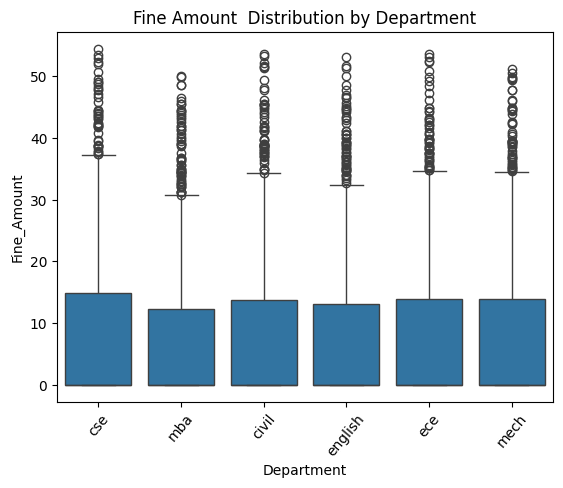

In [51]:
sns.boxplot(data=dt, x="Department", y="Fine_Amount")
plt.title("Fine Amount  Distribution by Department")
plt.xticks(rotation=50)
plt.show()


#**Insights**

Departments like CSE and ECE tend to accumulate higher fines, possibly due to heavier academic workload or delayed returns of technical books.

MBA and English departments show lower fine totals, suggesting better time management or lighter reading requirements.

In [52]:
display(round(raw.groupby("Year")["Fine_Amount"].sum(),2))

,Fine_Amount
Year,
1st,11725.99
2nd,11956.96
3rd,11637.55
4th,12648.71


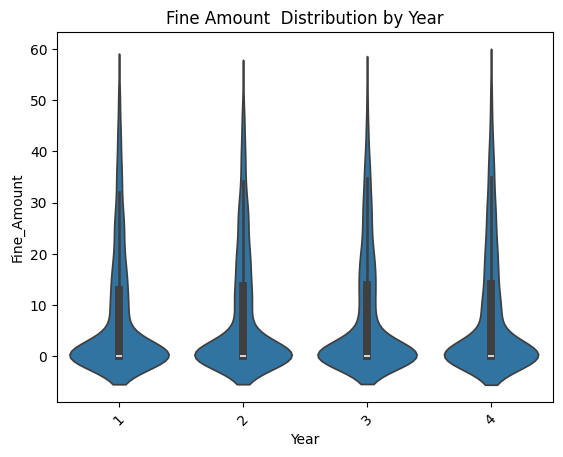

In [53]:
sns.violinplot(data=dt, x="Year", y="Fine_Amount")
plt.title("Fine Amount  Distribution by Year")
plt.xticks(rotation=45)
plt.show()


#**Insights**

Fine amounts are evenly distributed across years, confirming consistent borrowing behavior and return discipline.

A slight rise in fines for 3rd and 4th years could indicate project or research pressure delaying returns.


In [54]:
display(round(raw.groupby("Category")["Rating"].count()))

,Rating
Category,
ai & ml,720
data science,818
engineering,802
fiction,756
history,772
literature,747
management,697
philosophy,688


In [72]:
group = round(dt.groupby("Category", as_index=False)["Rating"].count(),2)
px.pie(group, names='Category', values='Rating', width=600, height=350)

#**Insights**

Categories like Data Science and Engineering receive more ratings, showing strong engagement and popularity among students.

Philosophy and Management have fewer ratings, implying they are less frequently borrowed or reviewed.


In [73]:
display(round(raw.groupby("Category")["Fine_Amount"].sum()))

,Fine_Amount
Category,
ai & ml,5875.00
data science,6195.00
engineering,6113.00
fiction,6028.00
history,6406.00
literature,6138.00
management,6040.00
philosophy,5175.00


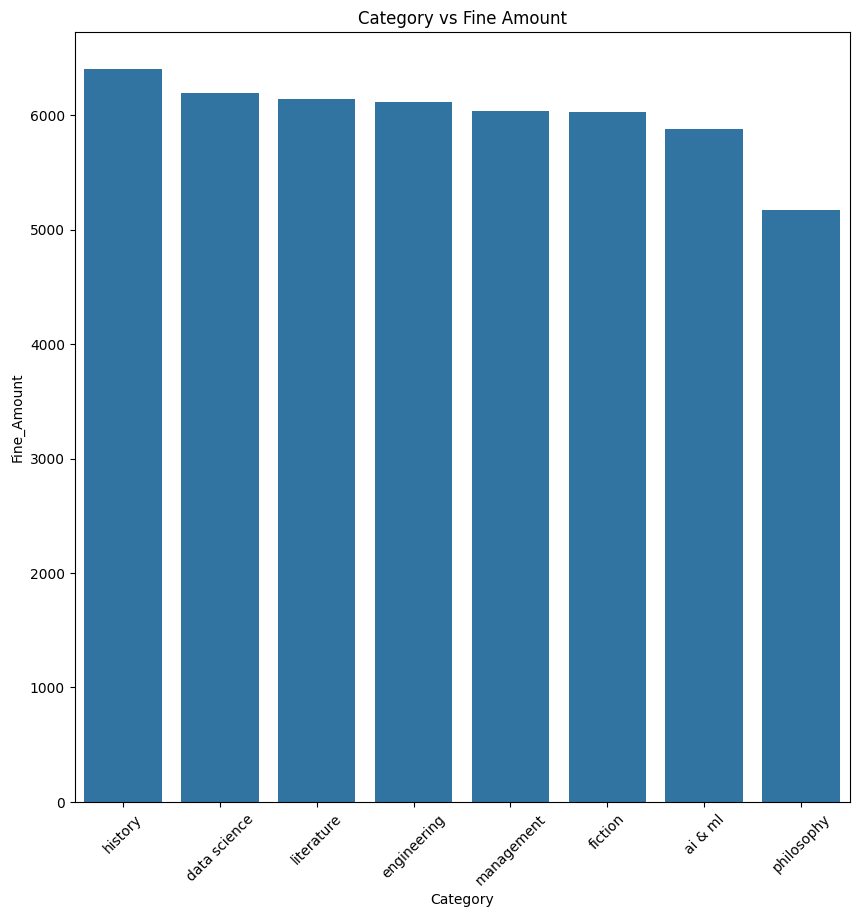

In [74]:
plt.figure(figsize=(10,10))
group = dt.groupby("Category", as_index=False)["Fine_Amount"].sum().sort_values("Fine_Amount", ascending=False).head(10)
sns.barplot(data=group, x="Category", y="Fine_Amount")
plt.title("Category vs Fine Amount")
plt.xticks(rotation=45)
plt.show()


#**Insights**

Categories with high fines (like AI or Research Methods) suggest long-term usage or difficulty completing reading within time limits.

Novels or Poetry categories have lower fines, reflecting casual reading patterns and quicker returns.

**Pure Categorical**



1.   Category vs Department

1.   Year vs Category



In [58]:
pd.crosstab(raw["Category"],raw["Department"])

Department,civil,cse,ece,english,mba,mech
Category,,,,,,
ai & ml,129,124,123,115,118,111
data science,131,143,138,147,113,146
engineering,126,115,148,160,129,124
fiction,129,144,121,121,121,120
history,126,127,134,116,137,132
literature,104,119,134,108,136,146
management,122,106,120,108,112,129
philosophy,105,116,116,105,110,136


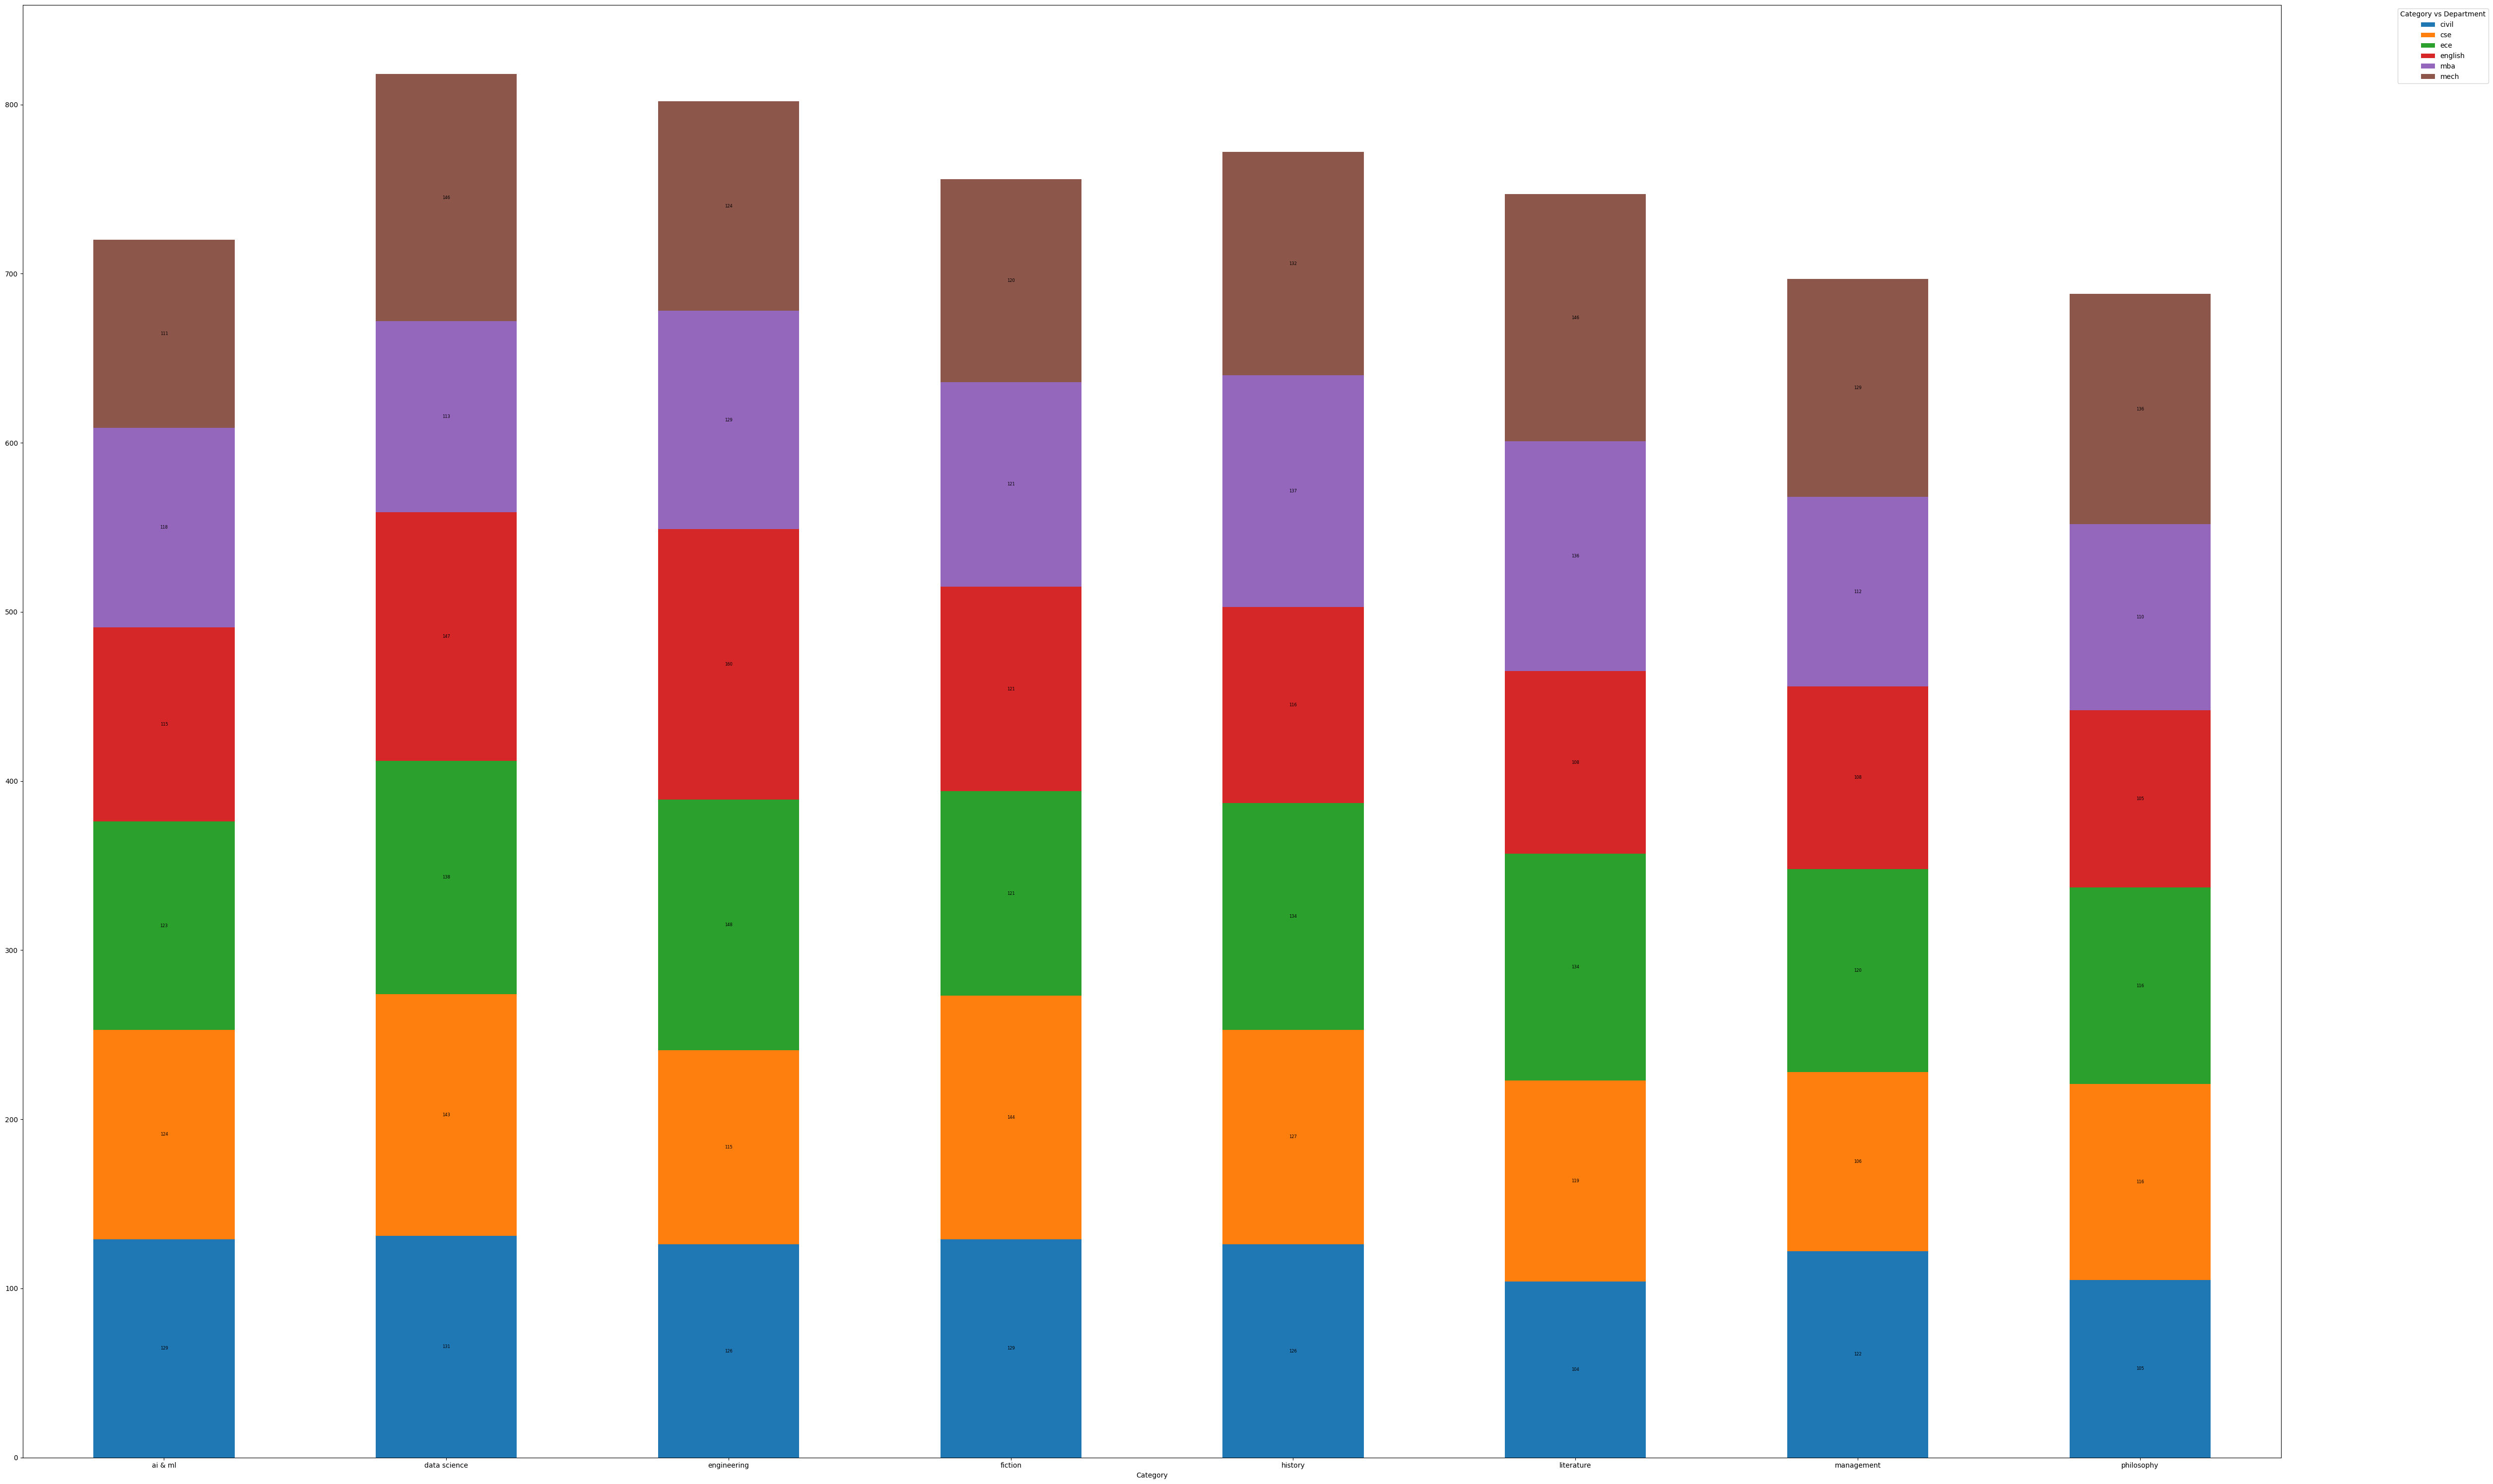

In [59]:
ctab = pd.crosstab(raw['Category'], raw['Department'])

ax = ctab.plot(kind="bar", stacked=True, rot=0, figsize=(50, 30))

for c in ax.containers:
    ax.bar_label(c, label_type='center', fontsize=6)

plt.legend(title='Category vs Department', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#**Insights**

**Departmental Specialization:**

Each department shows a clear preference for specific categories — for example, CSE students borrow more Data Science, AI, and Machine Learning books, while English students favor Literature and Poetry.

In [60]:
pd.crosstab(raw["Year"],raw["Category"])

Category,ai & ml,data science,engineering,fiction,history,literature,management,philosophy
Year,,,,,,,,
1st,185,213,194,197,190,201,156,172
2nd,174,196,208,188,201,184,167,165
3rd,183,204,193,175,187,186,181,168
4th,178,205,207,196,194,176,193,183


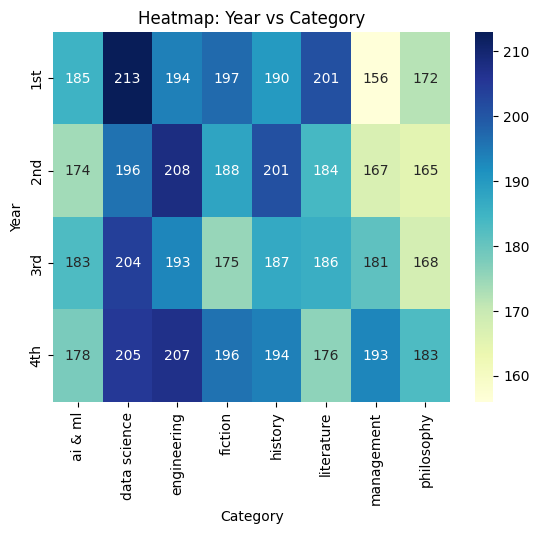

In [61]:

cross = pd.crosstab(raw["Year"], raw["Category"])
sns.heatmap(cross, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Heatmap: Year vs Category")
plt.show()

#**Insights**

**Academic Progression Pattern:**

Early-year students (1st & 2nd year) borrow more Fundamentals and Introduction books, while 3rd & 4th-year students prefer advanced topics like AI, Data Science, and Research Methods.

**Multi-Variate Analysis**

**Pure Numeric**



1.   Year vs Days Borrowed vs Fine Amount
   



In [62]:
#pure numeric
display(round(dt[['Year','Days_Borrowed','Fine_Amount']].corr(),2))

,Year,Days_Borrowed,Fine_Amount
Year,1.00,0.02,0.01
Days_Borrowed,0.02,1.00,0.79
Fine_Amount,0.01,0.79,1.00


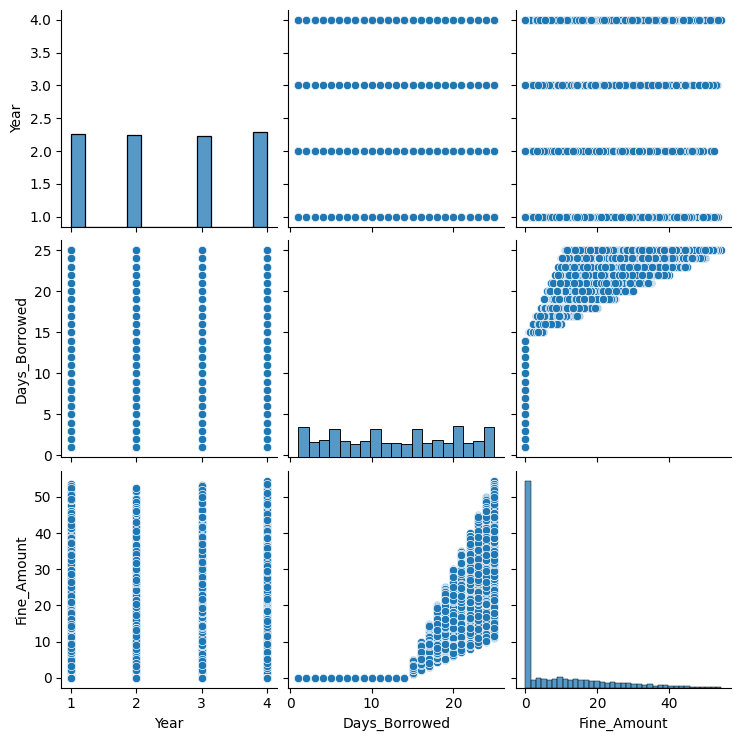

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(dt[['Year','Days_Borrowed','Fine_Amount']])
plt.show()


#**Insights**

**Strong Days–Fine Link:**

Days_Borrowed and Fine_Amount show a high positive correlation, confirming that longer borrow durations directly increase fines — a clear validation of the library’s fine calculation policy.


**Mixed**

2. Department vs Category vs Days Borrowed

In [64]:
#mixed
display(round(raw.groupby(['Department','Category'])['Days_Borrowed'].describe(),2))

count  mean  std  min   25%   50%   75%   max
Department Category                                                   
civil      ai & ml      129.00 12.67 7.53 1.00  6.00 13.00 20.00 25.00
           data science 131.00 12.79 6.66 1.00  8.00 14.00 17.00 25.00
           engineering  126.00 12.56 7.53 1.00  5.25 13.00 19.00 25.00
           fiction      129.00 14.02 7.67 1.00  8.00 15.00 21.00 25.00
           history      126.00 12.38 7.39 1.00  6.00 12.00 19.00 25.00
           literature   104.00 14.42 7.40 1.00  8.00 15.50 21.00 25.00
           management   122.00 14.52 7.14 1.00  9.00 16.00 21.00 25.00
           philosophy   105.00 11.94 7.20 1.00  6.00 11.00 17.00 25.00
cse        ai & ml      124.00 14.26 7.43 1.00  6.75 15.00 21.00 25.00
           data science 143.00 12.40 7.39 1.00  6.00 12.00 18.00 25.00
           engineering  115.00 12.86 7.14 1.00  7.00 12.00 19.00 25.00
           fiction      144.00 12.91 7.55 1.00  6.00 12.50 20.00 25.00
           history      127.00 14.34 7.10 1.00  9.00 15.00 21.00 25.00
           literature   119.00 13.27 7.64 1.00  6.00 13.00 20.00 25.00
           management   106.00 14.34 7.13 1.00  8.25 14.00 21.00 25.00
           philosophy   116.00 12.87 7.13 1.00  7.00 12.50 19.00 25.00
ece        ai & ml      123.00 13.37 7.29 1.00  6.50 14.00 20.00 25.00
           data science 138.00 12.74 6.86 1.00  7.00 12.50 18.00 25.00
           engineering  148.00 12.47 7.40 1.00  6.00 12.00 19.00 25.00
           fiction      121.00 12.56 7.28 1.00  7.00 12.00 19.00 25.00
           history      134.00 13.01 7.16 1.00  7.00 13.00 19.00 25.00
           literature   134.00 13.78 7.00 1.00  7.25 14.00 20.00 25.00
           management   120.00 12.22 7.22 1.00  6.00 11.50 20.00 25.00
           philosophy   116.00 13.96 7.29 1.00  7.00 15.00 20.00 25.00
english    ai & ml      115.00 12.98 6.89 1.00  8.00 14.00 18.50 25.00
           data science 147.00 13.63 7.19 1.00  7.50 14.00 20.00 25.00
           engineering  160.00 12.27 6.83 1.00  7.00 11.00 18.00 25.00
           fiction      121.00 12.13 7.07 1.00  7.00 12.00 18.00 25.00
           history      116.00 12.76 7.35 1.00  6.75 12.00 18.00 25.00
           literature   108.00 12.52 7.47 1.00  6.00 12.00 19.00 25.00
           management   108.00 12.86 7.66 1.00  5.00 12.00 20.00 25.00
           philosophy   105.00 12.65 7.08 1.00  7.00 12.00 19.00 25.00
mba        ai & ml      118.00 12.76 6.86 1.00  7.00 12.50 18.00 25.00
           data science 113.00 13.27 7.59 1.00  5.00 13.00 20.00 25.00
           engineering  129.00 13.51 7.72 1.00  6.00 15.00 20.00 25.00
           fiction      121.00 12.81 7.49 1.00  6.00 13.00 19.00 25.00
           history      137.00 12.72 7.40 1.00  7.00 13.00 19.00 25.00
           literature   136.00 11.10 7.41 1.00  5.00 10.00 18.00 25.00
           management   112.00 12.55 7.53 1.00  5.75 11.00 20.00 25.00
           philosophy   110.00 14.06 6.53 1.00 10.00 15.00 18.75 25.00
mech       ai & ml      111.00 13.19 7.55 1.00  6.00 13.00 19.50 25.00
           data science 146.00 13.07 7.20 1.00  7.25 13.00 19.00 25.00
           engineering  124.00 13.44 7.21 1.00  7.00 14.00 19.00 25.00
           fiction      120.00 12.78 7.32 1.00  6.00 12.00 20.00 25.00
           history      132.00 13.33 7.20 1.00  7.00 13.50 19.00 25.00
           literature   146.00 12.86 7.66 1.00  6.00 12.00 20.00 25.00
           management   129.00 12.82 7.39 1.00  6.00 13.00 20.00 25.00
           philosophy   136.00 12.71 7.24 1.00  6.00 12.00 19.00 25.00

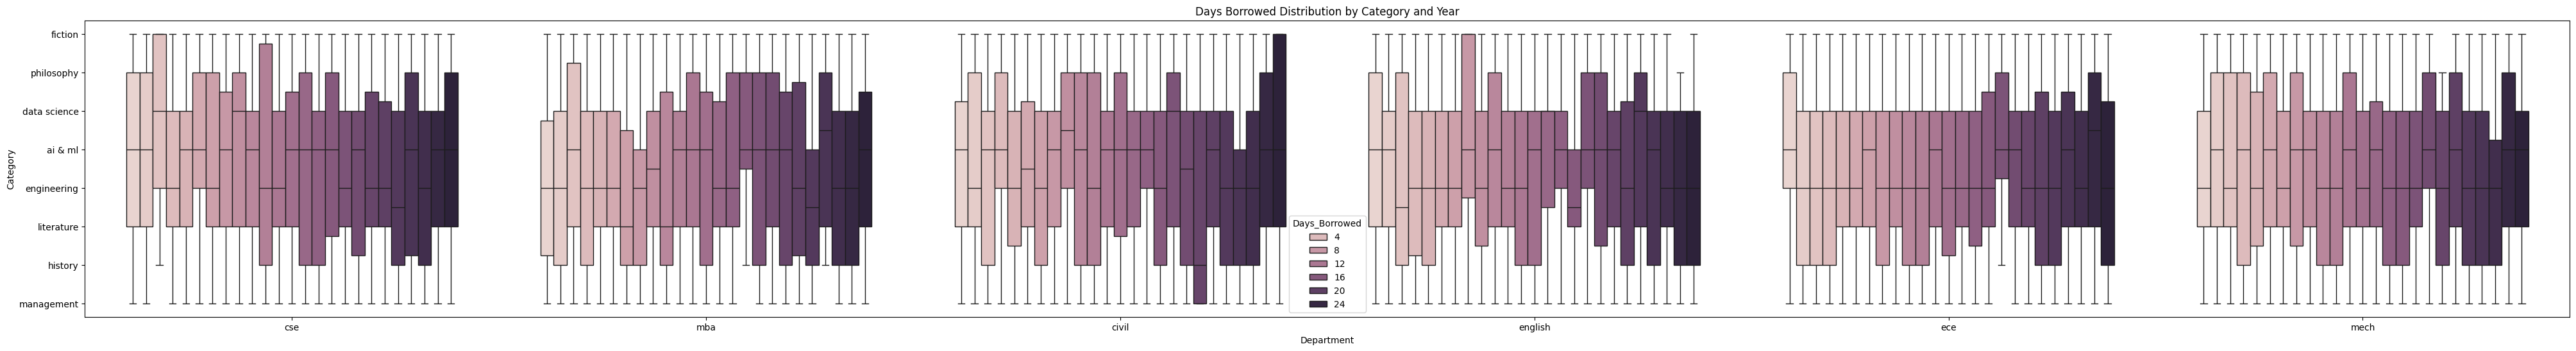

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(50,6))
sns.boxplot(data=dt, x='Department', y='Category', hue='Days_Borrowed')
plt.title('Days Borrowed Distribution by Category and Year')
plt.show()


#**Insights**

**Departmental Borrowing Trends:**

CSE and ECE students have longer average borrowing durations, particularly for AI and Data Science books, reflecting high engagement with technical resources.



**pure categorical**

3. Year vs Department vs Category

In [67]:
pd.crosstab(raw['Year'],[raw['Department'],raw['Category'],raw["Days_Borrowed"]])

Department      civil                             ...       mech              \
Category      ai & ml                             ... philosophy               
Days_Borrowed      1  2  3  4  5  6  7  8  9  10  ...         16 17 18 19 20   
Year                                              ...                          
1st                 1  1  5  5  2  1  3  0  1  1  ...          2  0  2  1  4   
2nd                 3  0  5  3  0  1  0  1  2  1  ...          0  4  3  2  0   
3rd                 1  0  1  0  0  2  2  2  0  2  ...          1  0  0  4  1   
4th                 3  0  0  0  0  1  2  1  2  2  ...          1  2  2  2  1   

Department                    
Category                      
Days_Borrowed 21 22 23 24 25  
Year                          
1st            1  0  0  1  1  
2nd            1  2  0  1  3  
3rd            1  2  2  1  1  
4th            3  0  0  2  1  

[4 rows x 1189 columns]

In [68]:
px.sunburst(raw, path=['Year','Department','Category'], values='Days_Borrowed')

#**Insights**
**Hierarchical Borrowing Behavior:**

The sunburst chart reveals a nested pattern — each academic year connects to specific departments, which in turn favor particular book categories (e.g., CSE → AI/Data Science).



#**Overall Insights**

Technical categories are most popular — Data Science, AI & ML, and Engineering books are borrowed most, especially by CSE and ECE students.

Senior students borrow more advanced topics, while juniors focus on foundational subjects and leisure reading.

Borrowing duration averages ~13 days, and longer borrow periods lead to higher fines (strong Days_Borrowed vs Fine_Amount correlation).

Fines are generally low, indicating most students return books on time; only a few students incur high fines.

Library usage is fairly balanced across departments and years, with slight peaks in MECH and ECE departments.

Some categories are underutilized — Philosophy, Management, and Literature have fewer borrowings, suggesting areas for promotion or redistribution.

Curriculum influences borrowing patterns — advanced subjects and project-related books are favored in later years, which can guide targeted resource planning and acquisition.



In [69]:
import json

# Mount Google Drive if you want to save there
from google.colab import drive
drive.mount('/content/drive')

# Load your notebook (already running in Colab)
# Corrected path to save the notebook in Google Drive
notebook_path = "/content/drive/MyDrive/library usage analytics.ipynb"
json_path = "/content/drive/MyDrive/library usage analytics.json"

# In Colab, the current notebook is not directly accessible as a file in the file system.
# To save the notebook, you can use the Colab API or manually save it through the UI.
# However, if you want to save the *data* from the notebook to a file, you can do so.
# The code below saves the raw DataFrame to a JSON file in your Google Drive.

# Assuming 'raw' is the DataFrame you want to save
# You can replace 'raw' with the variable containing your notebook data if needed.
# To save the notebook content itself programmatically, you would typically use Colab's API,
# but direct file system access to the running .ipynb is not available.

# Example of saving a DataFrame to JSON:
# data_to_save = raw.to_json(orient='records')
# with open(json_path, "w") as f:
#     f.write(data_to_save)

# If you intended to save the notebook file itself, you can do this manually in Colab
# by going to File -> Save a copy in Drive.

print(f"Data (if saving a variable like 'raw') would be saved to: {json_path}")
print("To save the notebook file, please use File -> Save a copy in Drive.")

Mounted at /content/drive
Data (if saving a variable like 'raw') would be saved to: /content/drive/MyDrive/library usage analytics.json
To save the notebook file, please use File -> Save a copy in Drive.
